In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

In [3]:
from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3523s 21us/step


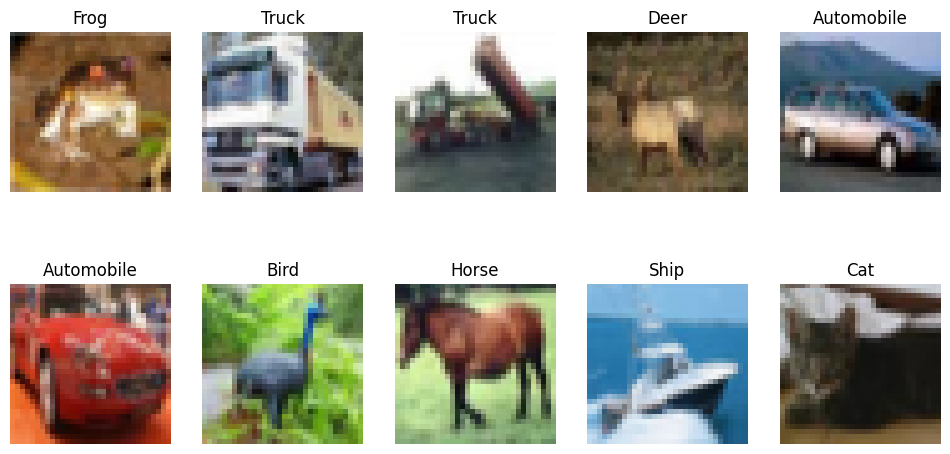

In [4]:
class_names = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [5]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [6]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [7]:
model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Dropout
model.add(Dropout(0.25))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 82ms/step - accuracy: 0.3826 - loss: 1.6868 - val_accuracy: 0.5218 - val_loss: 1.3585
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 82ms/step - accuracy: 0.5024 - loss: 1.3908 - val_accuracy: 0.5932 - val_loss: 1.1892
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.5437 - loss: 1.2725 - val_accuracy: 0.6168 - val_loss: 1.0935
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.5799 - loss: 1.1936 - val_accuracy: 0.6510 - val_loss: 1.0090
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 80ms/step - accuracy: 0.6005 - loss: 1.1397 - val_accuracy: 0.6636 - val_loss: 0.9842
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 83ms/step - accuracy: 0.6158 - loss: 1.0954 - val_accuracy: 0.6542 - val_loss: 0.9753
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 82ms/step - accuracy: 0.6290 - loss: 1.0481 - val_accuracy: 0.6742 - val_loss: 0.9480
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 79ms/step - accuracy: 0.6440 - loss: 1.0107 - 

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6981 - loss: 0.8726
Test Accuracy: 0.6980999708175659


# Visualize Training & Validation Accuracy and Loss (Question 2.3(b))

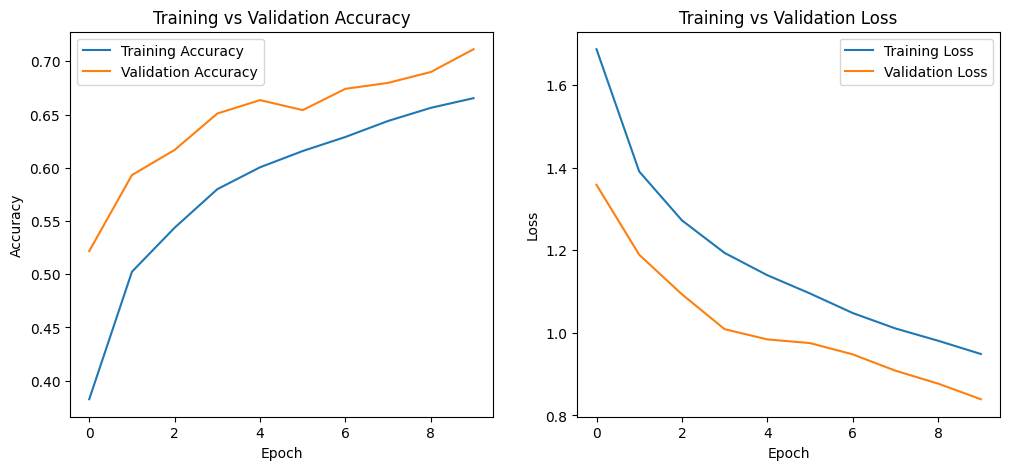

In [12]:
# Plot Accuracy

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Data Augmentation (Question 2.3(c))

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

In [14]:
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=64
)

In [15]:
history_aug = model.fit(
    train_generator,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 115ms/step - accuracy: 0.5890 - loss: 1.1837 - val_accuracy: 0.6707 - val_loss: 0.9522
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 114ms/step - accuracy: 0.5996 - loss: 1.1579 - val_accuracy: 0.6831 - val_loss: 0.9101
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step - accuracy: 0.6101 - loss: 1.1304 - val_accuracy: 0.6704 - val_loss: 0.9661
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.6102 - loss: 1.1217 - val_accuracy: 0.6918 - val_loss: 0.8964
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.6177 - loss: 1.0971 - val_accuracy: 0.7045 - val_loss: 0.8636
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.6209 - loss: 1.0904 - val_accuracy: 0.6820 - val_loss: 0.9015
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 113ms/step - accuracy: 0.6285 - loss: 1.0745 - val_accuracy: 0.6958 - val_loss: 0.9012
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.6294 - loss: 1

In [16]:
loss_no_aug, acc_no_aug = model.evaluate(X_test, y_test)

print("Accuracy after Data Augmentation:", acc_no_aug)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7081 - loss: 0.8372
Accuracy after Data Augmentation: 0.7081000208854675


# Feature Map Visualization (Question 2.3(d))

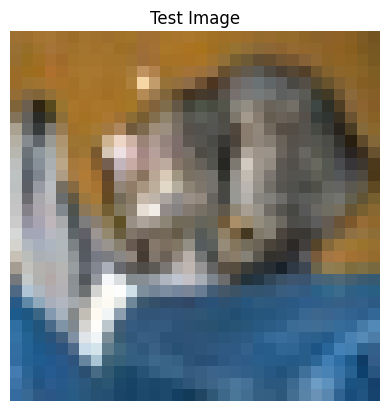

In [17]:
sample = X_test[0]

plt.imshow(sample)
plt.title("Test Image")
plt.axis("off")
plt.show()

In [18]:
sample = np.expand_dims(sample, axis=0)

In [21]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D

conv_layers = []

for layer in model.layers:
    if isinstance(layer, Conv2D):
        conv_layers.append(layer.output)

feature_model = Model(
    inputs=model.layers[0].input,
    outputs=conv_layers
)

In [22]:
feature_maps = feature_model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


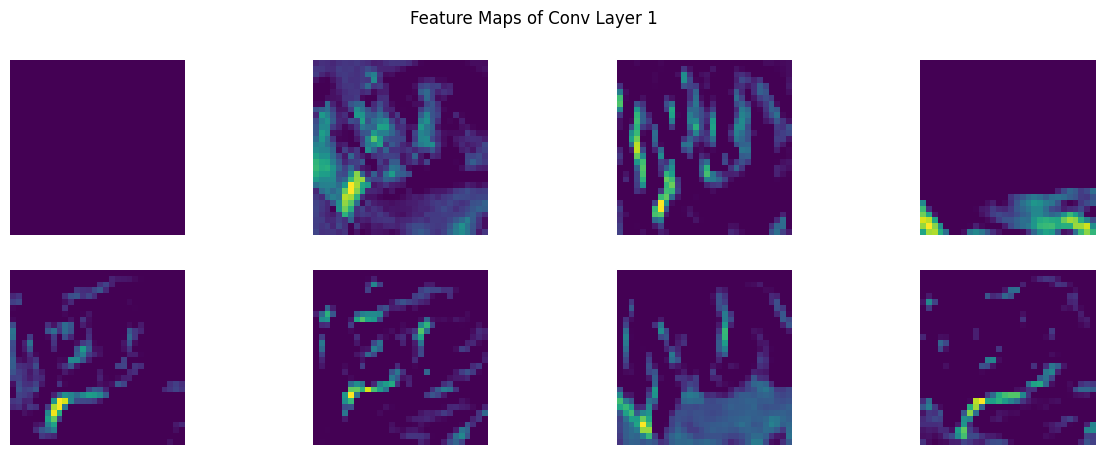

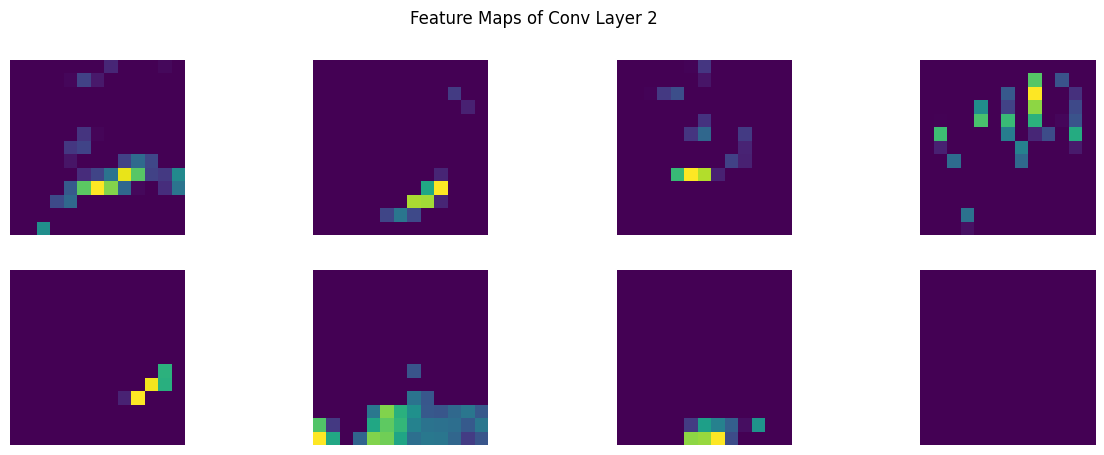

In [23]:
for i, fmap in enumerate(feature_maps):

    plt.figure(figsize=(15,5))

    for j in range(min(8, fmap.shape[-1])):

        plt.subplot(2,4,j+1)
        plt.imshow(fmap[0,:,:,j], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f'Feature Maps of Conv Layer {i+1}')
    plt.show()

# CNN Inference Pipeline (Question 2.3(e))

In [26]:
import numpy as np

sample = np.expand_dims(X_test[10], axis=0)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print("Predicted Label :", class_names[predicted_class])
print("Confidence Score :", confidence * 100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Label : Airplane
Confidence Score : 64.28482 %
